In [54]:
# ─────────────────────────────────────────────────────────────
# NB03 — EfficientNet-B0 Two-Stage ABMIL Training (PyTorch)
# ─────────────────────────────────────────────────────────────
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import timm
from sklearn.metrics import (
    f1_score, recall_score, roc_auc_score,
    roc_curve, confusion_matrix
)
from sklearn.calibration import calibration_curve

# ── Environment check ─────────────────────────────────────────
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print(f"timm     : {timm.__version__}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.10.0+cu128
CUDA     : True
timm     : 1.0.26
GPU      : Tesla T4


In [55]:
# ─────────────────────────────────────────────────────────────
# All paths defined once here — nothing hardcoded elsewhere
# ─────────────────────────────────────────────────────────────
NB02 = Path(
    "/kaggle/input/notebooks/mfjmrizvi/02-mil-patch-extraction"
)
OUT  = Path("/kaggle/working")

# ── Input files from NB02 ─────────────────────────────────────
X_TRAIN_PATH        = NB02 / "X_train_patches.npy"
Y_TRAIN_PATH        = NB02 / "y_train_labels.npy"
BAG_IDS_TRAIN_PATH  = NB02 / "bag_ids_train.npy"
TRAIN_BAG_IDX_PATH  = NB02 / "train_bag_indices.npy"
VAL_BAG_IDX_PATH    = NB02 / "val_bag_indices.npy"
CLASS_WEIGHTS_PATH  = NB02 / "class_weights.json"

X_TEST_PATH         = NB02 / "X_test_patches.npy"
Y_TEST_PATH         = NB02 / "y_test_labels.npy"
BAG_IDS_TEST_PATH   = NB02 / "bag_ids_test.npy"

# ── Output files ──────────────────────────────────────────────
S1_WEIGHTS   = OUT / "efficientnet_b0_stage1.pth"
S2_WEIGHTS   = OUT / "efficientnet_b0_stage2.pth"
RESULTS_JSON = OUT / "efficientnet_b0_results.json"

print("NB02 path exists:", NB02.exists())
print("Output dir      :", OUT)

NB02 path exists: True
Output dir      : /kaggle/working


In [56]:
# ─────────────────────────────────────────────────────────────
# All tunable values in one place — nothing magic-numbered
# in training loops below
# ─────────────────────────────────────────────────────────────
MODEL_NAME   = "efficientnet_b0"
FEAT_DIM     = 1280          # confirmed from NB02 verification
ATTN_DIM     = 128

PATCH_SIZE   = 224
SEED         = 42

# Stage 1 — patch level
BS_STAGE1    = 128           # patches are small, large batch fine
LR_STAGE1    = 1e-3
EPOCHS_S1    = 15
PATIENCE_S1  = 5

# Stage 2 — bag level (backbone frozen, feature cache used)
LR_S2_HEAD   = 1e-4
EPOCHS_S2    = 30
PATIENCE_S2  = 7

# ImageNet normalisation stats (applied after 0-1 rescaling)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda


In [57]:
# ─────────────────────────────────────────────────────────────
# Load all NB02 outputs and print shapes to confirm
# ─────────────────────────────────────────────────────────────
print("Loading arrays...")
X_train_all  = np.load(X_TRAIN_PATH)   # (19770, 224, 224, 1) float32
y_train_all  = np.load(Y_TRAIN_PATH)   # (19770,) int
bag_ids_all  = np.load(BAG_IDS_TRAIN_PATH)  # (19770,) int

train_bag_indices = np.load(TRAIN_BAG_IDX_PATH)  # (1061,)
val_bag_indices   = np.load(VAL_BAG_IDX_PATH)    # (257,)

X_test_all   = np.load(X_TEST_PATH)    # (5997, 224, 224, 1) float32
y_test_all   = np.load(Y_TEST_PATH)    # (5997,) int
bag_ids_test = np.load(BAG_IDS_TEST_PATH)  # (5997,) int

with open(CLASS_WEIGHTS_PATH) as f:
    raw_cw = json.load(f)
class_weight_dict = {int(k): float(v) for k, v in raw_cw.items()}

# ── Sanity checks ─────────────────────────────────────────────
print("\n── Train arrays ──")
print(f"X_train_all : {X_train_all.shape}  dtype={X_train_all.dtype}"
      f"  range=[{X_train_all.min():.3f}, {X_train_all.max():.3f}]")
print(f"y_train_all : {y_train_all.shape}  "
      f"benign={( y_train_all==0).sum()}  "
      f"malignant={(y_train_all==1).sum()}")
print(f"bag_ids_all : {bag_ids_all.shape}  "
      f"unique bags={len(np.unique(bag_ids_all))}")

print("\n── Split indices ──")
print(f"train_bag_indices : {train_bag_indices.shape}")
print(f"val_bag_indices   : {val_bag_indices.shape}")
overlap = set(train_bag_indices) & set(val_bag_indices)
print(f"Patient overlap   : {len(overlap)}  (must be 0)")

print("\n── Test arrays ──")
print(f"X_test_all : {X_test_all.shape}")
print(f"y_test_all : {y_test_all.shape}  "
      f"benign={(y_test_all==0).sum()}  "
      f"malignant={(y_test_all==1).sum()}")

print("\n── Class weights ──")
print(class_weight_dict)

Loading arrays...

── Train arrays ──
X_train_all : (19770, 224, 224, 1)  dtype=float32  range=[0.000, 1.000]
y_train_all : (19770,)  benign=13616  malignant=6154
bag_ids_all : (19770,)  unique bags=1318

── Split indices ──
train_bag_indices : (1061,)
val_bag_indices   : (257,)
Patient overlap   : 0  (must be 0)

── Test arrays ──
X_test_all : (5997, 224, 224, 1)
y_test_all : (5997,)  benign=4620  malignant=1377

── Class weights ──
{0: 0.7259841363102233, 1: 1.6062723431914203}


In [58]:
# ─────────────────────────────────────────────────────────────
# Split patches using precomputed patient-level bag indices
# ─────────────────────────────────────────────────────────────
train_mask = np.isin(bag_ids_all, train_bag_indices)
val_mask   = np.isin(bag_ids_all, val_bag_indices)

X_tr     = X_train_all[train_mask]
y_tr     = y_train_all[train_mask]
bag_tr   = bag_ids_all[train_mask]

X_val    = X_train_all[val_mask]
y_val    = y_train_all[val_mask]
bag_val  = bag_ids_all[val_mask]

print("── After split ──")
print(f"Train patches : {X_tr.shape}  "
      f"benign={(y_tr==0).sum()}  malignant={(y_tr==1).sum()}")
print(f"Val   patches : {X_val.shape}  "
      f"benign={(y_val==0).sum()}  malignant={(y_val==1).sum()}")
print(f"Train bags    : {len(np.unique(bag_tr))}")
print(f"Val   bags    : {len(np.unique(bag_val))}")

── After split ──
Train patches : (16198, 224, 224, 1)  benign=11356  malignant=4842
Val   patches : (3572, 224, 224, 1)  benign=2260  malignant=1312
Train bags    : 1061
Val   bags    : 257


In [59]:
# ─────────────────────────────────────────────────────────────
# Convert (N, 224, 224, 1) numpy float32 [0,1]
#   → (N, 3, 224, 224) torch float32, ImageNet normalised
#
# Patches are already 0-1 from NB02 — do NOT divide by 255
# ImageNet normalisation is model-specific so it lives here,
# not in NB02
# ─────────────────────────────────────────────────────────────
_mean = torch.tensor(IMAGENET_MEAN, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
_std  = torch.tensor(IMAGENET_STD,  dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)

def numpy_to_tensor(X_np: np.ndarray) -> torch.Tensor:
    """
    X_np : (N, 224, 224, 1) float32, values in [0, 1]
    Returns (N, 3, 224, 224) float32 tensor on DEVICE,
    ImageNet normalised.
    """
    t = torch.from_numpy(X_np).float()          # (N,224,224,1)
    t = t.permute(0, 3, 1, 2)                   # (N,1,224,224)
    t = t.repeat(1, 3, 1, 1)                    # (N,3,224,224)
    t = t.to(DEVICE)
    t = (t - _mean) / _std
    return t

# ── Quick test ────────────────────────────────────────────────
_test = numpy_to_tensor(X_tr[:4])
print("Preprocess test:", _test.shape, _test.dtype,
      f"mean≈{_test.mean().item():.3f}")
del _test

Preprocess test: torch.Size([4, 3, 224, 224]) torch.float32 mean≈0.353


In [60]:
# ─────────────────────────────────────────────────────────────
# Stage 1 Dataset 
# ─────────────────────────────────────────────────────────────
_mean_gpu = torch.tensor(IMAGENET_MEAN, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
_std_gpu  = torch.tensor(IMAGENET_STD,  dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)

class PatchDataset(Dataset):
    def __init__(self, X_np: np.ndarray, y_np: np.ndarray):
        """
        X_np : (N, 224, 224, 1) float32
        y_np : (N,) int
        """
        self.X = X_np
        self.y = torch.from_numpy(y_np).float()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Simply hand over the single-channel patch to the DataLoader
        patch = self.X[idx]                         # (224,224,1)
        patch = torch.from_numpy(patch).float()     # (224,224,1)
        return patch.permute(2, 0, 1), self.y[idx]  # Returns (1, 224, 224) and label

In [61]:
# ─────────────────────────────────────────────────────────────
# Stage 2 Dataset
# ─────────────────────────────────────────────────────────────
class BagDataset(Dataset):
    def __init__(self,
                 X_np:      np.ndarray,
                 y_np:      np.ndarray,
                 bag_ids:   np.ndarray,
                 bag_list:  np.ndarray):
        self.X        = X_np
        self.y        = y_np
        self.bag_ids  = bag_ids
        self.bag_list = bag_list

    def __len__(self):
        return len(self.bag_list)

    def __getitem__(self, idx):
        bid   = self.bag_list[idx]
        mask  = self.bag_ids == bid
        patches = self.X[mask]           # (N_k, 224, 224, 1)
        labels  = self.y[mask]           # (N_k,)

        t = torch.from_numpy(patches).float()   # (N_k,224,224,1)
        t = t.permute(0, 3, 1, 2)               # (N_k,1,224,224)
        t = t.repeat(1, 3, 1, 1)                # (N_k,3,224,224)
        
        # Variable-size adjustments for normalization tensors on CPU
        m = _mean_cpu.unsqueeze(0)   # (1, 3, 1, 1)
        s = _std_cpu.unsqueeze(0)    # (1, 3, 1, 1)
        t = (t - m) / s

        bag_label = torch.tensor(labels[0], dtype=torch.float32)
        return t, bag_label

In [62]:
# ─────────────────────────────────────────────────────────────
# GPU Strategy for Stage 2:
#   Precompute backbone features ONCE for all patches
#   Store as (N, FEAT_DIM) tensor
#   Stage 2 training loop iterates over cached features only
#   Backbone makes zero forward passes per epoch after caching
#   This is only valid while backbone is fully frozen
# ─────────────────────────────────────────────────────────────
class CachedBagDataset(Dataset):
    """
    Like BagDataset but operates on pre-extracted feature vectors
    instead of raw patches. Used when backbone is frozen.

    features : (N_patches, FEAT_DIM) float32 tensor or numpy
    y_np     : (N_patches,) int
    bag_ids  : (N_patches,) int
    bag_list : (N_bags,)   int
    """
    def __init__(self,
                 features:  np.ndarray,
                 y_np:      np.ndarray,
                 bag_ids:   np.ndarray,
                 bag_list:  np.ndarray):
        self.features  = features
        self.y         = y_np
        self.bag_ids   = bag_ids
        self.bag_list  = bag_list

    def __len__(self):
        return len(self.bag_list)

    def __getitem__(self, idx):
        bid  = self.bag_list[idx]
        mask = self.bag_ids == bid
        
        # This safely creates a CPU tensor from your pre-computed features array
        h    = torch.from_numpy(self.features[mask]).float()     # (N_k, FEAT_DIM)
        
        bag_label = torch.tensor(
                        self.y[mask][0],
                        dtype=torch.float32)
        return h, bag_label


def collate_cached(batch):
    """
    Groups variable-sized patch feature tensors into a list,
    preventing DataLoader shape mismatch crashes.
    """
    features_list = [item[0] for item in batch]
    labels        = torch.stack([item[1] for item in batch])
    return features_list, labels

In [63]:
# ─────────────────────────────────────────────────────────────
# Build EfficientNet-B0 backbone via timm
# num_classes=0 → GAP applied, returns flat feature vector
# ─────────────────────────────────────────────────────────────
def build_backbone(model_name: str,
                   pretrained: bool = True) -> nn.Module:
    model = timm.create_model(
        model_name,
        pretrained=pretrained,
        num_classes=0        # removes classifier head, keeps GAP
    )
    return model

backbone = build_backbone(MODEL_NAME, pretrained=True)
backbone = backbone.to(DEVICE)

# ── Confirm feature dimension ──────────────────────────────────
with torch.no_grad():
    _dummy = torch.zeros(2, 3, PATCH_SIZE, PATCH_SIZE,
                         device=DEVICE)
    _out   = backbone(_dummy)
    print(f"Backbone output shape : {_out.shape}")
    print(f"Expected FEAT_DIM     : {FEAT_DIM}")
    assert _out.shape[1] == FEAT_DIM, (
        f"Feature dim mismatch: got {_out.shape[1]}, "
        f"expected {FEAT_DIM}"
    )
del _dummy, _out
print("Backbone verified.")

Backbone output shape : torch.Size([2, 1280])
Expected FEAT_DIM     : 1280
Backbone verified.


In [64]:
# ─────────────────────────────────────────────────────────────
# Stage 1: backbone + single linear head for patch classification
# No sigmoid — BCEWithLogitsLoss handles it numerically
# ─────────────────────────────────────────────────────────────
class PatchClassifier(nn.Module):
    def __init__(self, backbone: nn.Module, feat_dim: int):
        super().__init__()
        self.backbone = backbone
        self.head     = nn.Linear(feat_dim, 1)

    def forward(self, x):
        # x : (B, 3, 224, 224)
        h   = self.backbone(x)    # (B, feat_dim)
        out = self.head(h)        # (B, 1)
        return out.squeeze(1)     # (B,)

In [65]:
# ─────────────────────────────────────────────────────────────
# ABMIL attention head (Ilse et al. 2018)
#
# Given N patch feature vectors h_k ∈ R^feat_dim:
#   a_k = softmax( w^T tanh(V h_k) )   across k=1..N
#   z   = sum_k( a_k * h_k )            bag representation
#
# Returns both z and a so attention weights can be visualised
# ─────────────────────────────────────────────────────────────
class AttentionPool(nn.Module):
    def __init__(self, feat_dim: int, attn_dim: int):
        super().__init__()
        self.V = nn.Linear(feat_dim, attn_dim, bias=True)
        self.w = nn.Linear(attn_dim, 1,        bias=False)

    def forward(self, h: torch.Tensor):
        """
        h : (N, feat_dim)   — N patches in one bag
        Returns:
            z : (1, feat_dim)  — bag representation
            a : (N, 1)         — attention weights (sum to 1)
        """
        a = self.w(torch.tanh(self.V(h)))  # (N, 1) raw scores
        a = torch.softmax(a, dim=0)        # (N, 1) normalised
        z = torch.sum(a * h, dim=0, keepdim=True)  # (1, feat_dim)
        return z, a

In [66]:
# ─────────────────────────────────────────────────────────────
# Stage 2: AttentionPool + bag-level head
# Backbone is NOT included here because Stage 2 uses cached
# features — backbone made zero forward passes per epoch
# If you later partially unfreeze backbone, attach it here
# ─────────────────────────────────────────────────────────────
class BagClassifier(nn.Module):
    def __init__(self, feat_dim: int, attn_dim: int):
        super().__init__()
        self.attn = AttentionPool(feat_dim, attn_dim)
        self.head = nn.Linear(feat_dim, 1)

    def forward(self, h: torch.Tensor):
        """
        h   : (N, feat_dim)  — cached features for one bag
        Returns:
            logit : scalar
            a     : (N, 1) attention weights
        """
        z, a  = self.attn(h)        # z: (1, feat_dim)
        logit = self.head(z)        # (1, 1)
        return logit.squeeze(), a

In [67]:
# ─────────────────────────────────────────────────────────────
# Stage 1: patch-level pre-training setup
# ─────────────────────────────────────────────────────────────
patch_model = PatchClassifier(backbone, FEAT_DIM).to(DEVICE)

# pos_weight = weight_positive / weight_negative
# BCEWithLogitsLoss expects a single scalar tensor, not a dict
pos_weight_val = class_weight_dict[1] / class_weight_dict[0]
criterion_s1   = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight_val, device=DEVICE)
)
print(f"pos_weight for BCEWithLogitsLoss: {pos_weight_val:.4f}")

optimiser_s1  = optim.Adam(patch_model.parameters(), lr=LR_STAGE1)
scheduler_s1  = optim.lr_scheduler.ReduceLROnPlateau(
    optimiser_s1, mode='min', factor=0.5,
    patience=3
)

train_patch_ds = PatchDataset(X_tr,  y_tr)
val_patch_ds   = PatchDataset(X_val, y_val)

train_patch_dl = DataLoader(train_patch_ds, batch_size=BS_STAGE1,
                             shuffle=True,  num_workers=2,
                             pin_memory=True)
val_patch_dl   = DataLoader(val_patch_ds,   batch_size=BS_STAGE1,
                             shuffle=False, num_workers=2,
                             pin_memory=True)

print(f"Train batches : {len(train_patch_dl)}")
print(f"Val   batches : {len(val_patch_dl)}")

pos_weight for BCEWithLogitsLoss: 2.2125
Train batches : 127
Val   batches : 28


In [69]:
# ─────────────────────────────────────────────────────────────
# Stage 1 training loop (With GPU Vectorization & AMP)
# ─────────────────────────────────────────────────────────────
scaler = torch.amp.GradScaler('cuda')

s1_history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_f1": []}
best_val_loss_s1    = float("inf")
patience_counter_s1 = 0
t0 = time.time()

for epoch in range(1, EPOCHS_S1 + 1):
    patch_model.train()
    running_loss = 0.0
    for patches, labels in train_patch_dl:
        # 1. Push raw single-channel patches to GPU memory immediately
        patches, labels = patches.to(DEVICE), labels.to(DEVICE) # Shape: (BS, 1, 224, 224)
        
        # 2. Parallelized channel expansion and normalization on GPU cores
        patches = patches.repeat(1, 3, 1, 1)                   # Expand to (BS, 3, 224, 224)
        patches = (patches - _mean_gpu) / _std_gpu             # Fast GPU broadcasting math
        
        optimiser_s1.zero_grad()
        
        # 3. Forward pass wrapped in AMP autocast to optimize VRAM
        with torch.amp.autocast('cuda'):
            logits = patch_model(patches)
            loss = criterion_s1(logits, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimiser_s1)
        scaler.update()
        
        running_loss += loss.item() * len(labels)
    train_loss = running_loss / len(train_patch_dl.dataset)

    # ─────────────────────────────────────────────────────────
    # Validation Phase
    # ─────────────────────────────────────────────────────────
    patch_model.eval()
    val_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for patches, labels in val_patch_dl:
            patches, labels = patches.to(DEVICE), labels.to(DEVICE)
            
            # Identical fast GPU transformations
            patches = patches.repeat(1, 3, 1, 1)
            patches = (patches - _mean_gpu) / _std_gpu
            
            with torch.amp.autocast('cuda'):
                logits   = patch_model(patches)
                loss_val = criterion_s1(logits, labels)
                
            val_loss += loss_val.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    val_loss  /= len(val_patch_dl.dataset)
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    val_preds  = (all_probs >= 0.5).astype(int)
    val_auc    = roc_auc_score(all_labels, all_probs)
    val_f1     = f1_score(all_labels, val_preds, zero_division=0)

    s1_history["train_loss"].append(train_loss)
    s1_history["val_loss"].append(val_loss)
    s1_history["val_auc"].append(val_auc)
    s1_history["val_f1"].append(val_f1)
    scheduler_s1.step(val_loss)

    print(f"Ep {epoch:02d}/{EPOCHS_S1}  "
          f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
          f"val_auc={val_auc:.4f}  val_f1={val_f1:.4f}")

    if val_loss < best_val_loss_s1:
        best_val_loss_s1    = val_loss
        patience_counter_s1 = 0
        torch.save(patch_model.state_dict(), S1_WEIGHTS)
        print("  ✓ Saved best Stage 1 weights")
    else:
        patience_counter_s1 += 1
        if patience_counter_s1 >= PATIENCE_S1:
            print(f"  Early stopping at epoch {epoch}")
            break

print(f"\nStage 1 complete — {(time.time()-t0)/60:.1f} min")

Ep 01/15  train_loss=0.3505  val_loss=0.9126  val_auc=0.8058  val_f1=0.6740
  ✓ Saved best Stage 1 weights
Ep 02/15  train_loss=0.2495  val_loss=1.0773  val_auc=0.8124  val_f1=0.6726
Ep 03/15  train_loss=0.1645  val_loss=1.4040  val_auc=0.8112  val_f1=0.6867
Ep 04/15  train_loss=0.1146  val_loss=1.6722  val_auc=0.7920  val_f1=0.6669
Ep 05/15  train_loss=0.0545  val_loss=1.7830  val_auc=0.8099  val_f1=0.6785
Ep 06/15  train_loss=0.0298  val_loss=1.9185  val_auc=0.8033  val_f1=0.6675
  Early stopping at epoch 6

Stage 1 complete — 4.5 min


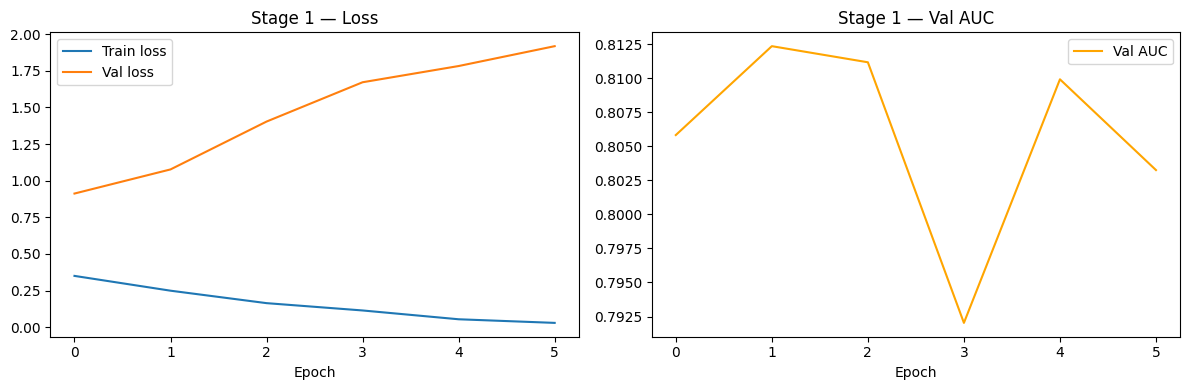

Saved stage1_training_curves.png


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(s1_history["train_loss"], label="Train loss")
axes[0].plot(s1_history["val_loss"],   label="Val loss")
axes[0].set_title("Stage 1 — Loss"); axes[0].legend()
axes[0].set_xlabel("Epoch")

axes[1].plot(s1_history["val_auc"], label="Val AUC", color="orange")
axes[1].set_title("Stage 1 — Val AUC"); axes[1].legend()
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(OUT / "stage1_training_curves.png", dpi=150)
plt.show()
print("Saved stage1_training_curves.png")

In [71]:
# ─────────────────────────────────────────────────────────────
# Stage 1 patch-level diagnostic metrics
# ─────────────────────────────────────────────────────────────
patch_model.load_state_dict(
    torch.load(S1_WEIGHTS, map_location=DEVICE))
patch_model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for patches, labels in val_patch_dl:
        patches = patches.to(DEVICE)
        
        # Identical fast GPU transformations
        patches = patches.repeat(1, 3, 1, 1)
        patches = (patches - _mean_gpu) / _std_gpu
        
        with torch.amp.autocast('cuda'):
            all_probs.extend(
                torch.sigmoid(patch_model(patches)).cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
preds      = (all_probs >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

s1_metrics = {
    "patch_auc"        : float(roc_auc_score(all_labels, all_probs)),
    "patch_f1"         : float(f1_score(all_labels, preds, zero_division=0)),
    "patch_sensitivity": float(recall_score(all_labels, preds, zero_division=0)),
    "patch_specificity": float(tn / (tn + fp)),
}
print("── Stage 1 Patch-Level Val Metrics ──")
for k, v in s1_metrics.items():
    print(f"  {k:25s}: {v:.4f}")

── Stage 1 Patch-Level Val Metrics ──
  patch_auc                : 0.8058
  patch_f1                 : 0.6740
  patch_sensitivity        : 0.6532
  patch_specificity        : 0.8345


In [72]:
# ─────────────────────────────────────────────────────────────
# Precompute backbone features for ALL patches (train, val, test)
# This happens ONCE with frozen backbone
# Stage 2 training loop then only updates the attention head
# Result: zero backbone forward passes per Stage 2 epoch
# ─────────────────────────────────────────────────────────────

# Use backbone from patch_model (already loaded with best S1 weights)
feature_extractor = patch_model.backbone
feature_extractor.eval()
for p in feature_extractor.parameters():
    p.requires_grad_(False)

def extract_features(X_np: np.ndarray,
                     model: nn.Module,
                     batch_size: int = 256) -> np.ndarray:
    """
    X_np  : (N, 224, 224, 1) float32
    Returns (N, FEAT_DIM) float32 numpy
    """
    all_feats = []
    n = len(X_np)
    model.eval()
    with torch.no_grad():
        for start in range(0, n, batch_size):
            batch = X_np[start : start + batch_size]
            t     = numpy_to_tensor(batch)          # (B,3,224,224)
            feats = model(t).cpu().numpy()          # (B, FEAT_DIM)
            all_feats.append(feats)
    return np.concatenate(all_feats, axis=0)

print("Extracting train features...")
feats_tr  = extract_features(X_tr,        feature_extractor)
print(f"  train : {feats_tr.shape}")

print("Extracting val features...")
feats_val = extract_features(X_val,       feature_extractor)
print(f"  val   : {feats_val.shape}")

print("Extracting test features...")
feats_test = extract_features(X_test_all, feature_extractor)
print(f"  test  : {feats_test.shape}")

Extracting train features...
  train : (16198, 1280)
Extracting val features...
  val   : (3572, 1280)
Extracting test features...
  test  : (5997, 1280)


In [73]:
# ─────────────────────────────────────────────────────────────
# Stage 2: attention head only — backbone is the feature cache
# ─────────────────────────────────────────────────────────────
bag_model = BagClassifier(FEAT_DIM, ATTN_DIM).to(DEVICE)

criterion_s2  = nn.BCEWithLogitsLoss()
# No pos_weight here — loss is at bag level, not patch level

optimiser_s2  = optim.Adam(bag_model.parameters(),
                            lr=LR_S2_HEAD)
scheduler_s2  = optim.lr_scheduler.ReduceLROnPlateau(
    optimiser_s2, mode='min', factor=0.5,
    patience=3
)

# ── Bag-level labels (one per bag, from patch labels) ─────────
def get_bag_labels(y_np: np.ndarray,
                   bag_ids: np.ndarray,
                   bag_list: np.ndarray) -> np.ndarray:
    """Return array of bag-level labels in bag_list order."""
    bag_labels = {}
    for bid in bag_list:
        mask = bag_ids == bid
        bag_labels[bid] = int(y_np[mask][0])
    return np.array([bag_labels[b] for b in bag_list])

train_bag_labels = get_bag_labels(y_tr,  bag_tr,  train_bag_indices)
val_bag_labels   = get_bag_labels(y_val, bag_val, val_bag_indices)
test_bag_labels  = get_bag_labels(y_test_all, bag_ids_test,
                                   np.unique(bag_ids_test))

# CachedBagDataset uses precomputed features
train_bag_ds = CachedBagDataset(feats_tr,   y_tr,       bag_tr,
                                 train_bag_indices)
val_bag_ds   = CachedBagDataset(feats_val,  y_val,      bag_val,
                                 val_bag_indices)

train_bag_dl = DataLoader(train_bag_ds, batch_size=1,
                           shuffle=True,  collate_fn=collate_cached)
val_bag_dl   = DataLoader(val_bag_ds,   batch_size=1,
                           shuffle=False, collate_fn=collate_cached)

print(f"Train bags : {len(train_bag_ds)}")
print(f"Val   bags : {len(val_bag_ds)}")

Train bags : 1061
Val   bags : 257


In [74]:
s2_history = {"train_loss": [], "val_loss": [],
               "val_auc":   [], "val_f1":   []}
best_val_loss_s2 = float("inf")
patience_counter_s2 = 0
t0 = time.time()

for epoch in range(1, EPOCHS_S2 + 1):

    # ── Train ─────────────────────────────────────────────────
    bag_model.train()
    running_loss = 0.0
    for h_list, labels in train_bag_dl:
        # h_list : list of length 1 (batch_size=1)
        # h_list[0] : (N_k, FEAT_DIM) — one bag's features
        h      = h_list[0].to(DEVICE)
        label  = labels[0].to(DEVICE)          # scalar
        optimiser_s2.zero_grad()
        logit, _ = bag_model(h)
        loss     = criterion_s2(logit, label)
        loss.backward()
        optimiser_s2.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_bag_ds)

    # ── Validate ──────────────────────────────────────────────
    bag_model.eval()
    val_loss   = 0.0
    val_probs  = []
    val_true   = []
    with torch.no_grad():
        for h_list, labels in val_bag_dl:
            h     = h_list[0].to(DEVICE)
            label = labels[0].to(DEVICE)
            logit, _ = bag_model(h)
            loss  = criterion_s2(logit, label)
            val_loss += loss.item()
            val_probs.append(torch.sigmoid(logit).item())
            val_true.append(label.item())
    val_loss /= len(val_bag_ds)

    val_probs = np.array(val_probs)
    val_true  = np.array(val_true)
    val_preds = (val_probs >= 0.5).astype(int)
    val_auc   = roc_auc_score(val_true, val_probs)
    val_f1    = f1_score(val_true, val_preds, zero_division=0)

    s2_history["train_loss"].append(train_loss)
    s2_history["val_loss"].append(val_loss)
    s2_history["val_auc"].append(val_auc)
    s2_history["val_f1"].append(val_f1)

    scheduler_s2.step(val_loss)

    print(f"Ep {epoch:02d}/{EPOCHS_S2}  "
          f"train_loss={train_loss:.4f}  "
          f"val_loss={val_loss:.4f}  "
          f"val_auc={val_auc:.4f}  "
          f"val_f1={val_f1:.4f}")

    if val_loss < best_val_loss_s2:
        best_val_loss_s2 = val_loss
        patience_counter_s2 = 0
        torch.save(bag_model.state_dict(), S2_WEIGHTS)
        print("  ✓ Saved best Stage 2 weights")
    else:
        patience_counter_s2 += 1
        if patience_counter_s2 >= PATIENCE_S2:
            print(f"  Early stopping at epoch {epoch}")
            break

print(f"\nStage 2 complete — {(time.time()-t0)/60:.1f} min")

Ep 01/30  train_loss=0.0818  val_loss=0.0826  val_auc=0.9942  val_f1=0.9790
  ✓ Saved best Stage 2 weights
Ep 02/30  train_loss=0.0087  val_loss=0.0933  val_auc=0.9938  val_f1=0.9754
Ep 03/30  train_loss=0.0058  val_loss=0.1081  val_auc=0.9940  val_f1=0.9718
Ep 04/30  train_loss=0.0043  val_loss=0.1311  val_auc=0.9943  val_f1=0.9689
Ep 05/30  train_loss=0.0035  val_loss=0.1569  val_auc=0.9943  val_f1=0.9689
Ep 06/30  train_loss=0.0028  val_loss=0.1750  val_auc=0.9946  val_f1=0.9556
Ep 07/30  train_loss=0.0019  val_loss=0.1966  val_auc=0.9949  val_f1=0.9492
Ep 08/30  train_loss=0.0013  val_loss=0.2153  val_auc=0.9940  val_f1=0.9492
  Early stopping at epoch 8

Stage 2 complete — 0.3 min


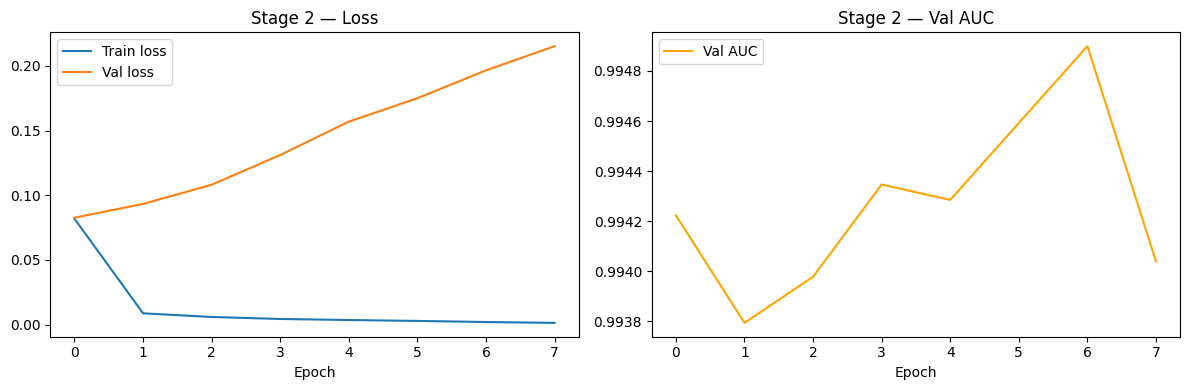

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(s2_history["train_loss"], label="Train loss")
axes[0].plot(s2_history["val_loss"],   label="Val loss")
axes[0].set_title("Stage 2 — Loss"); axes[0].legend()
axes[0].set_xlabel("Epoch")

axes[1].plot(s2_history["val_auc"], label="Val AUC", color="orange")
axes[1].set_title("Stage 2 — Val AUC"); axes[1].legend()
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(OUT / "stage2_training_curves.png", dpi=150)
plt.show()

In [76]:
# ─────────────────────────────────────────────────────────────
# Load best Stage 2 weights and collect bag-level predictions
# ─────────────────────────────────────────────────────────────
bag_model.load_state_dict(torch.load(S2_WEIGHTS,
                           map_location=DEVICE))
bag_model.eval()

val_bag_probs = []
val_bag_true  = []
with torch.no_grad():
    for h_list, labels in val_bag_dl:
        h     = h_list[0].to(DEVICE)
        logit, _ = bag_model(h)
        val_bag_probs.append(torch.sigmoid(logit).item())
        val_bag_true.append(labels[0].item())

val_bag_probs = np.array(val_bag_probs)
val_bag_true  = np.array(val_bag_true)
print(f"Val bags: {len(val_bag_probs)}")
print(f"Label distribution: benign={( val_bag_true==0).sum()}"
      f"  malignant={(val_bag_true==1).sum()}")

Val bags: 257
Label distribution: benign=113  malignant=144


In [77]:
fpr_c, tpr_c, thresholds_c = roc_curve(val_bag_true, val_bag_probs)

# Find lowest threshold giving sensitivity >= 0.90
idx = np.argmax(tpr_c >= 0.90)
optimal_threshold = float(thresholds_c[idx])

print(f"Default threshold (0.5) sensitivity : "
      f"{tpr_c[np.argmin(np.abs(thresholds_c - 0.5))]:.4f}")
print(f"Calibrated threshold                : {optimal_threshold:.4f}")
print(f"Sensitivity at calibrated threshold : {tpr_c[idx]:.4f}")
print(f"FPR at calibrated threshold         : {fpr_c[idx]:.4f}")

Default threshold (0.5) sensitivity : 0.9722
Calibrated threshold                : 0.9065
Sensitivity at calibrated threshold : 0.9444
FPR at calibrated threshold         : 0.0000


In [78]:
def compute_all_metrics(y_true, y_probs, threshold,
                         label="") -> dict:
    y_pred = (y_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr_val     = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    # ECE: 10 equal-width bins
    prob_true, prob_pred = calibration_curve(
        y_true, y_probs, n_bins=10, strategy='uniform'
    )
    # Weighted by bin population
    bin_edges = np.linspace(0, 1, 11)
    bin_counts = np.histogram(y_probs, bins=bin_edges)[0]
    ece = float(np.sum(
        bin_counts[:len(prob_true)] *
        np.abs(prob_true - prob_pred)
    ) / len(y_probs))

    metrics = {
        "threshold"   : threshold,
        "auc"         : float(roc_auc_score(y_true, y_probs)),
        "f1"          : float(f1_score(y_true, y_pred,
                                        zero_division=0)),
        "sensitivity" : float(sensitivity),
        "specificity" : float(specificity),
        "fpr"         : float(fpr_val),
        "ece"         : ece,
    }
    if label:
        print(f"── {label} ──")
    for k, v in metrics.items():
        print(f"  {k:15s}: {v:.4f}")
    return metrics

val_metrics_default = compute_all_metrics(
    val_bag_true, val_bag_probs,
    threshold=0.5, label="Val — default threshold (0.5)"
)
print()
val_metrics_cal = compute_all_metrics(
    val_bag_true, val_bag_probs,
    threshold=optimal_threshold,
    label=f"Val — calibrated threshold ({optimal_threshold:.3f})"
)

── Val — default threshold (0.5) ──
  threshold      : 0.5000
  auc            : 0.9942
  f1             : 0.9790
  sensitivity    : 0.9722
  specificity    : 0.9823
  fpr            : 0.0177
  ece            : 0.0129

── Val — calibrated threshold (0.906) ──
  threshold      : 0.9065
  auc            : 0.9942
  f1             : 0.9714
  sensitivity    : 0.9444
  specificity    : 1.0000
  fpr            : 0.0000
  ece            : 0.0129


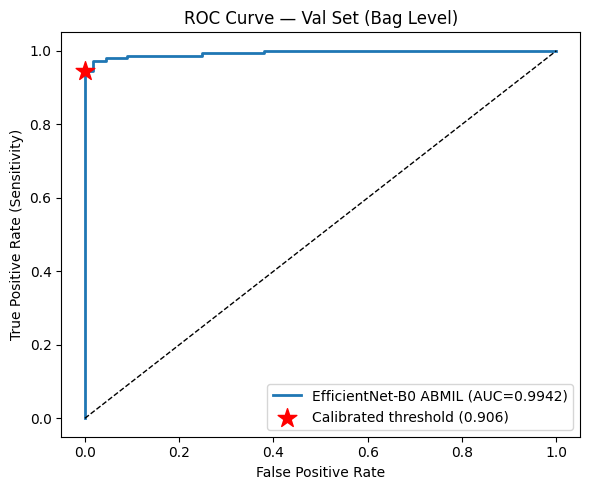

In [79]:
fpr_r, tpr_r, _ = roc_curve(val_bag_true, val_bag_probs)
auc_val = roc_auc_score(val_bag_true, val_bag_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr_r, tpr_r, lw=2,
         label=f"EfficientNet-B0 ABMIL (AUC={auc_val:.4f})")
plt.scatter([fpr_c[idx]], [tpr_c[idx]], marker='*', s=200,
            color='red', zorder=5,
            label=f"Calibrated threshold ({optimal_threshold:.3f})")
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — Val Set (Bag Level)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "efficientnet_b0_roc_curve.png", dpi=150)
plt.show()

In [80]:
# ─────────────────────────────────────────────────────────────
# Test set is touched ONCE — here only
# Threshold selected on val set — not touched again
# ─────────────────────────────────────────────────────────────
test_bag_list = np.unique(bag_ids_test)
test_bag_ds   = CachedBagDataset(feats_test, y_test_all,
                                  bag_ids_test, test_bag_list)
test_bag_dl   = DataLoader(test_bag_ds, batch_size=1,
                            shuffle=False, collate_fn=collate_cached)

test_bag_probs = []
test_bag_true  = []
bag_model.eval()
with torch.no_grad():
    for h_list, labels in test_bag_dl:
        h     = h_list[0].to(DEVICE)
        logit, _ = bag_model(h)
        test_bag_probs.append(torch.sigmoid(logit).item())
        test_bag_true.append(labels[0].item())

test_bag_probs = np.array(test_bag_probs)
test_bag_true  = np.array(test_bag_true)

print()
test_metrics = compute_all_metrics(
    test_bag_true, test_bag_probs,
    threshold=optimal_threshold,
    label=f"Test — calibrated threshold ({optimal_threshold:.3f})"
)


── Test — calibrated threshold (0.906) ──
  threshold      : 0.9065
  auc            : 0.9997
  f1             : 0.9866
  sensitivity    : 1.0000
  specificity    : 0.9827
  fpr            : 0.0173
  ece            : 0.0201


In [82]:
# ─────────────────────────────────────────────────────────────
# Collect attention weights for 4 malignant and 4 benign bags
# from the val set for visualisation
# ─────────────────────────────────────────────────────────────
mal_examples = []
ben_examples = []
bag_model.eval()

val_bag_iter = iter(val_bag_dl)
with torch.no_grad():
    for h_list, labels in val_bag_dl:
        if len(mal_examples) >= 4 and len(ben_examples) >= 4:
            break
        h     = h_list[0].to(DEVICE)
        label = int(labels[0].item())
        logit, attn_weights = bag_model(h)
        prob = torch.sigmoid(logit).item()
        entry = {
            "features"     : h.cpu().numpy(),       # (N_k, FEAT_DIM)
            "attn_weights" : attn_weights.cpu().numpy(),  # (N_k, 1)
            "true_label"   : label,
            "pred_prob"    : prob,
        }
        if label == 1 and len(mal_examples) < 4:
            mal_examples.append(entry)
        elif label == 0 and len(ben_examples) < 4:
            ben_examples.append(entry)

print(f"Malignant examples collected: {len(mal_examples)}")
print(f"Benign    examples collected: {len(ben_examples)}")

Malignant examples collected: 4
Benign    examples collected: 4


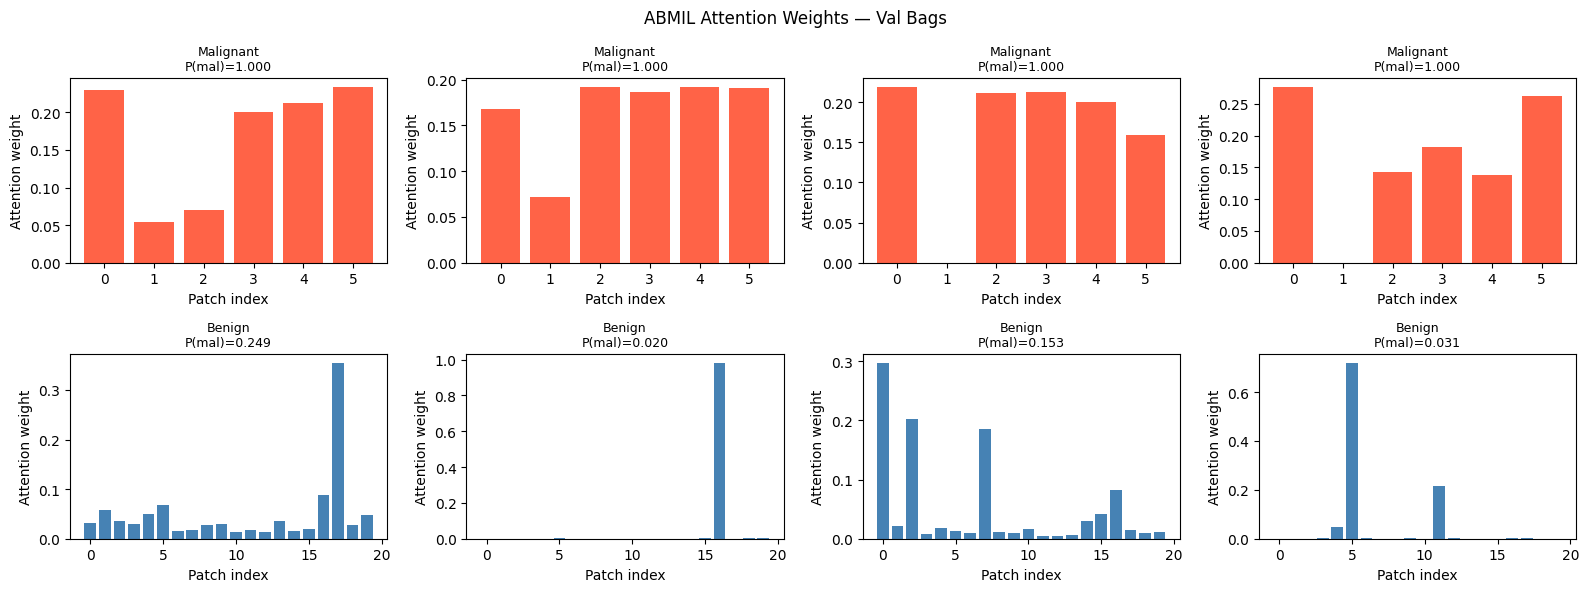

In [83]:
# ─────────────────────────────────────────────────────────────
# Visualise attention weights as bar charts (one bar per patch)
# Cannot overlay on mammogram because patch coordinates were
# not saved in NB02 — noted as a limitation
# ─────────────────────────────────────────────────────────────
all_examples = mal_examples + ben_examples
n = len(all_examples)
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, ex in enumerate(all_examples):
    weights = ex["attn_weights"].squeeze()     # (N_k,)
    label   = "Malignant" if ex["true_label"] == 1 else "Benign"
    prob    = ex["pred_prob"]
    color   = "tomato" if ex["true_label"] == 1 else "steelblue"
    axes[i].bar(range(len(weights)), weights, color=color)
    axes[i].set_title(f"{label}\nP(mal)={prob:.3f}",
                       fontsize=9)
    axes[i].set_xlabel("Patch index")
    axes[i].set_ylabel("Attention weight")

plt.suptitle("ABMIL Attention Weights — Val Bags", fontsize=12)
plt.tight_layout()
plt.savefig(OUT / "attention_examples.png", dpi=150)
plt.show()

In [84]:
results = {
    "model"              : MODEL_NAME,
    "feat_dim"           : FEAT_DIM,
    "attn_dim"           : ATTN_DIM,
    "stage1_metrics"     : s1_metrics,
    "val_metrics_default": val_metrics_default,
    "val_metrics_cal"    : val_metrics_cal,
    "test_metrics"       : test_metrics,
    "optimal_threshold"  : optimal_threshold,
    "hyperparameters"    : {
        "lr_stage1"   : LR_STAGE1,
        "lr_s2_head"  : LR_S2_HEAD,
        "epochs_s1"   : EPOCHS_S1,
        "epochs_s2"   : EPOCHS_S2,
        "bs_stage1"   : BS_STAGE1,
        "attn_dim"    : ATTN_DIM,
        "patience_s1" : PATIENCE_S1,
        "patience_s2" : PATIENCE_S2,
    }
}

with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=2)
print("Saved:", RESULTS_JSON)

Saved: /kaggle/working/efficientnet_b0_results.json


In [85]:
print("=" * 55)
print(f"  NB03 — {MODEL_NAME.upper()} ABMIL — FINAL RESULTS")
print("=" * 55)
print(f"  Stage 1 patch AUC     : "
      f"{s1_metrics['patch_auc']:.4f}")
print(f"  Optimal threshold     : {optimal_threshold:.4f}")
print()
print("  Val set (calibrated threshold):")
for k in ["auc","f1","sensitivity","fpr","ece"]:
    print(f"    {k:15s}: {val_metrics_cal[k]:.4f}")
print()
print("  Test set (calibrated threshold):")
for k in ["auc","f1","sensitivity","fpr","ece"]:
    print(f"    {k:15s}: {test_metrics[k]:.4f}")
print("=" * 55)

  NB03 — EFFICIENTNET_B0 ABMIL — FINAL RESULTS
  Stage 1 patch AUC     : 0.8058
  Optimal threshold     : 0.9065

  Val set (calibrated threshold):
    auc            : 0.9942
    f1             : 0.9714
    sensitivity    : 0.9444
    fpr            : 0.0000
    ece            : 0.0129

  Test set (calibrated threshold):
    auc            : 0.9997
    f1             : 0.9866
    sensitivity    : 1.0000
    fpr            : 0.0173
    ece            : 0.0201
